In [1]:
from langchain_openai import ChatOpenAI,OpenAIEmbeddings
from typing import TypedDict,List
from langgraph.graph import StateGraph,START,END,add_messages
from dotenv import load_dotenv
from langchain_core.prompts import ChatPromptTemplate
from langchain_community.document_loaders import PyPDFLoader
from langchain_core.documents import Document
from langchain_core.output_parsers import StrOutputParser,PydanticOutputParser
from langchain_text_splitters import RecursiveCharacterTextSplitter
from pydantic import BaseModel,Field
from langchain_community.vectorstores import FAISS
from langchain_huggingface import HuggingFaceEmbeddings

c:\Users\Jay Kanakia\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
loader1 = PyPDFLoader("documents/book1.pdf")
loader2 = PyPDFLoader("documents/book2.pdf")
loader3 = PyPDFLoader("documents/book3.pdf")

In [3]:
docs = loader1.load() + loader2.load() + loader3.load()
len(docs)

2123

In [4]:
splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap = 200
)

chunk = splitter.split_documents(docs)

len(chunk)

5918

In [5]:
load_dotenv()

model = ChatOpenAI()

In [ ]:
#embedding = OpenAIEmbeddings()

embedding = HuggingFaceEmbeddings(model_name="Qwen/Qwen3-Embedding-8B")

parser = StrOutputParser()

vector_store = FAISS.from_documents(
        embedding=embedding,
        documents=chunk
)

c:\Users\Jay Kanakia\AppData\Local\Programs\Python\Python311\Lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Jay Kanakia\.cache\huggingface\hub\models--Qwen--Qwen3-Embedding-8B. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

In [ ]:
retriever = vector_store.as_retriever(
    search_type = 'mmr',
    serach_kwargs = {'k':4}
)

In [10]:
class RagState(TypedDict):

    question : str
    documents : List[Document]

    good_docs : List[Document]
    verdict : str
    reason : str

    strip : List[str]
    kept_strip : List[str]
    refined_content : str

    answer : str

In [11]:
class KeepOrDrop(BaseModel):

    keep : bool = Field(description='True or False')

parser1 = PydanticOutputParser(pydantic_object=KeepOrDrop)

In [12]:
def retrieve(state:RagState)->dict:

    question = state['question']

    response = retriever.invoke(question)

    return {'documents':response}

In [13]:
import re

def decompose_to_sentences(text: str) -> List[str]:
    text = re.sub(r"\s+", " ", text).strip()
    sentences = re.split(r"(?<=[.!?])\s+", text)
    return [s.strip() for s in sentences if len(s.strip()) > 20]

In [25]:
def refine(state:RagState)->dict:

    refined_content = state.get('refined_content',"")

    question = state['question']

    #documents = state['documents']
    good_docs = state['good_docs']

    context = '\n'.join(f"- {docs.page_content}" for docs in good_docs)

    strips = decompose_to_sentences(context)

    template = ChatPromptTemplate([
        ('system',
         "You are a strict relevance filter.\n"
        "Return keep=true only if the sentence directly helps answer the question.\n"
        "Use ONLY the sentence. Output JSON only. \n"),
        ('user',"Question: {question}\n\nSentence:\n{sentence}")
    ],
    input_variables = ['question','sentence'],
    )

    kept : List[str] =[]

    model_with_structured_output = model.with_structured_output(KeepOrDrop)
    chain = template | model_with_structured_output 
    for s in strips:
        keep_drop : KeepOrDrop = chain.invoke({'question':question,'sentence':s})
        #keep_drop_dict = keep_drop.model_dump()
        if keep_drop.keep:
            kept.append(s)

    refined_content = ''.join(kept).strip()

    return {
        'strips':strips,
        'keep_strip':kept,
        'refined_content':refined_content
    }

In [32]:
def generate(state:RagState)->dict:

    question = state['question']
    documents = state['documents']
    
    content = '\n'.join(f" - {docs.page_content}" for docs in documents)


    template = ChatPromptTemplate([
        ('system',"Answer only from the context provided, if not in context say you don't know. \n {content}"),
        ('user',"{question}")
    ],
    input_variables = ['content','question']
    )

    chain = template | model | parser

    response = chain.invoke({'content':content,'question':question})

    return {'answer':response}

In [33]:
UPPER_TH = 0.7
LOWER_TH = 0.3

In [34]:
class DocEvalScore(BaseModel):

    score : float
    reason : str

#parser2 = PydanticOutputParser(pydantic_object=DocEvalScore)

template = ChatPromptTemplate([
    ('system',"You are a strict retrieval evaluator for RAG.\n"
            "You will be given ONE retrieved chunk and a question.\n"
            "Return a relevance score in [0.0, 1.0].\n"
            "- 1.0: chunk alone is sufficient to answer fully/mostly\n"
            "- 0.0: chunk is irrelevant\n"
            "Be conservative with high scores.\n"
            "Also return a short reason.\n"
            "Output JSON only. \n"),
    ('human',"Question: {question}\n\nChunk:\n{chunk}")
],
input_variables = ['question','chunk'],
)

model_with_structured_output = model.with_structured_output(DocEvalScore)

chain = template | model_with_structured_output 

def eval_each_node(state:RagState)->dict:

    question = state['question']
    documents = state['documents']

    score : List[float] = []
    reason : List[str] = []
    good_docs : List[Document] = []

    for doc in documents:
        doc_eval_score : DocEvalScore = chain.invoke({'question':question,'chunk':doc.page_content})
        #doc_eval_score_dict = doc_eval_score.model_dump()
        score.append(doc_eval_score.score)
        reason.append(doc_eval_score.reason)

        if doc_eval_score.score > LOWER_TH:
            good_docs.append(doc)

    if any(s > UPPER_TH for s in score):
        return {
            'good_docs':good_docs,
            'verdict':'CORRECT',
            'reason': f"At least one doc score is greater that {UPPER_TH}"
        }
    
    if len(score)>0 and all(s<LOWER_TH for s in score):
        return {
            'good_docs':[],
            'verdict':'INCORRECT',
            'reason': f"All doc score is less than {LOWER_TH}"
        }
    
    return {
        'good_docs':good_docs,
        'verdict':'AMBIGUOUS',
        'reason': f"No chunk scored > {UPPER_TH}, but not all were < {LOWER_TH}"
    }

c:\Users\Jay Kanakia\AppData\Local\Programs\Python\Python311\Lib\site-packages\langchain_openai\chat_models\base.py:2181: UserWarning: Cannot use method='json_schema' with model gpt-3.5-turbo since it doesn't support OpenAI's Structured Output API. You can see supported models here: https://platform.openai.com/docs/guides/structured-outputs#supported-models. To fix this warning, set `method='function_calling'. Overriding to method='function_calling'.
  warnings.warn(


In [35]:
def conditional_edge(state : RagState)->dict:
    verdict = state['verdict']

    if verdict == 'CORRECT':
        return "refine"
    elif verdict == 'INCORRECT':
        return "web_search"
    else:
        return "ambiguous"

def ambiguous(state:RagState)->dict:
    reason = state['reason']
    return {'answer':f"Ambiguous {reason}"}

def fail_node(state:RagState)->dict:
    reason = state['reason']
    return {'answer':f"FAIL : {reason}"}



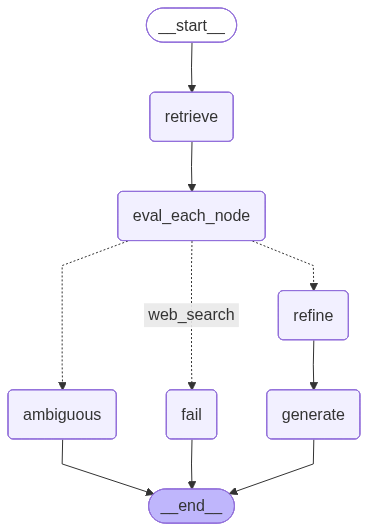

In [36]:
graph = StateGraph(RagState)
graph.add_node('retrieve',retrieve)
graph.add_node('refine',refine)
graph.add_node('generate',generate)
graph.add_node('eval_each_node',eval_each_node)
graph.add_node('ambiguous',ambiguous)
graph.add_node('fail',fail_node)

graph.add_edge(START,'retrieve')
graph.add_edge('retrieve','eval_each_node')
graph.add_conditional_edges('eval_each_node',conditional_edge,{'ambiguous':'ambiguous','web_search':'fail','refine':'refine'})
graph.add_edge('refine','generate')
graph.add_edge('generate',END)
graph.add_edge('ambiguous',END)
graph.add_edge('fail',END)

chatbot = graph.compile()

chatbot

In [45]:
response = chatbot.invoke({'question':'What are attention mechanisms and why are they important in current models and what are advantages and disadvantages'})

print(response)

{'question': 'What are attention mechanisms and why are they important in current models and what are advantages and disadvantages', 'documents': [Document(id='fbaab61b-3101-45cb-a9a9-ad5e64278b8d', metadata={'producer': 'iText 2.1.7 by 1T3XT', 'creator': 'PyPDF', 'creationdate': '', 'moddate': '2019-01-26T22:50:33+16:00', 'enhanced': 'By PDF Enhancer 3.5.6412/Unix', 'spdf': '1127', 'source': 'documents/book2.pdf', 'total_pages': 801, 'page': 491, 'page_label': '492'}, page_content='CHAPTER12.APPLICATIONS\nisbeingexpressed),thenproducethetranslatedwordsoneatatime,eachtime\nfocusingonadiﬀerentpartoftheinputsentenceinordertogatherthesemantic\ndetailsthatarerequiredtoproducethenextoutputword. Thatisexactlythe\nideathat ()ﬁrstintroduced.TheattentionmechanismusedBahdanauetal.2015\ntofocusonspeciﬁcpartsoftheinputsequenceateachtimestepisillustratedin\nﬁgure.12.6\nWecanthinkofanattention-basedsystemashavingthreecomponents:\n1.Aprocessthat“reads”rawdata(suchassourcewordsinasourcesentence),\nand

In [46]:
print(response['verdict'])
print(response['reason'])
response['answer']

CORRECT
At least one doc score is greater that 0.7


'Attention mechanisms are crucial components in current models because they allow the model to focus on specific parts of the input sequence at each time step, enabling better understanding and interpretation of the data. The advantages of attention mechanisms include improved performance in tasks such as machine translation, speech recognition, and natural language processing, as they help the model effectively capture long-range dependencies and important details. Additionally, attention mechanisms provide interpretability to the model, allowing users to understand why the model made certain decisions. \n\nSome disadvantages of attention mechanisms include increased computational complexity, as they require additional computational resources compared to models without attention. They may also require more training data to learn effectively, which can be a challenge in some applications. Additionally, designing the attention mechanism itself can be complex and may require domain exper

In [ ]:
# Bias variance tradeoff
# AI news from last week
# What are attention mechanisms and why are they important in current models?